# Gates, the gating strategy, and reading the numbers

A gate is a named region in one or two dimensions **plus the display scaling its
boundary was drawn on**. That last part is not decoration: the same vertices
mean different populations on a linear and a logicle axis, so a gate that does
not carry its transform cannot be re-applied, saved or shared honestly.

What a cytometrist actually has, though, is not a gate but a **strategy**:
debris, then singlets, then live, then lineage — each step evaluated only on the
events its parent kept. `ov.flow` models that tree as an object that belongs to
the *analysis* rather than to any one sample, which is what makes applying one
strategy to ninety files possible.

This notebook continues from
[reading and compensation](t_flow_01_reading_and_compensation.ipynb).

In [1]:
# No data of your own is needed. ov.datasets.flow_demo_fcs() writes a SIMULATED
# FCS 3.1 file into the current working directory: 59,600 events, nine known
# populations, a real $SPILLOVER keyword, and a detector noise floor that pushes
# dim events below zero — which is why a log display axis will not do.
import numpy as np, pathlib
import omicverse as ov

ov.style()          # omicverse's plotting defaults — call this once, up front

path = ov.datasets.flow_demo_fcs()
print(path)


/Users/fernandozeng/miniforge3/envs/omictest/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
✅ Apple Silicon MPS detected
    • [MPS] Apple Silicon GPU - Metal Performance Shaders available

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.4   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.

flow_demo.fcs


In [2]:
import omicverse as ov
import matplotlib.pyplot as plt
import numpy as np

adata = ov.datasets.flow_demo()      # = read_fcs(flow_demo_fcs()) + obs['population']
ov.flow.compensate(adata)

lin = ov.flow.Linear(t=262144.0)
lg  = ov.flow.Logicle(t=262144.0, m=4.5, w=1.0, a=0.0)
adata


AnnData object with n_obs × n_vars = 59600 × 8
    obs: 'sample', 'population'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnG', 'PnR'
    uns: 'meta', 'fcs', 'flow_demo', 'flow'
    layers: 'uncompensated'

## Gate geometry

Five kinds, following Gating-ML 2.0 so they round-trip through the interchange
format without a second representation:

| Gate | What it is |
|---|---|
| `RectangleGate` | axis-aligned interval in 1..n dims; `None` = unbounded, which is how "CD3 positive" is written without inventing a ceiling |
| `PolygonGate` | arbitrary 2-D region — the gate people actually draw |
| `EllipsoidGate` | Mahalanobis region, parameterised by covariance and squared distance |
| `QuadrantGate` | one divider per dimension → 2ⁿ populations that share their dividers |
| `BooleanGate` | AND / OR / NOT over populations already computed |

Note `at(600)` below. A threshold is a *data* value — 600 units of CD3 — and
writing it as the scale-space number it happens to equal is how a gate silently
drifts when the transform is retuned.

In [3]:
def at(v):
    """A data value expressed on the logicle scale — how a threshold is really
    written. Typing 0.42 instead of at(600) is how gates drift."""
    return float(lg.apply(np.array([float(v)]))[0])

cells = ov.flow.PolygonGate(
    name="Cells", dims=("FSC-A", "SSC-A"),
    transforms={"FSC-A": lin, "SSC-A": lin},
    vertices=np.array([[0.12,0.01],[0.12,0.17],[0.40,0.32],
                       [0.68,0.32],[0.68,0.09],[0.38,0.01]]))
singlets = ov.flow.PolygonGate(
    name="Singlets", dims=("FSC-A", "FSC-H"),
    transforms={"FSC-A": lin, "FSC-H": lin},
    vertices=np.array([[0.05,0.03],[0.05,0.10],[0.75,0.86],[0.75,0.69]]))
live = ov.flow.RectangleGate(
    name="Live", dims=("Viability",), transforms={"Viability": lg},
    bounds=((None, at(1200)),))
cd3 = ov.flow.RectangleGate(
    name="CD3+", dims=("CD3",), transforms={"CD3": lg},
    bounds=((at(600), None),))
quad = ov.flow.QuadrantGate(
    name="CD4/CD8", dims=("CD4", "CD8"), transforms={"CD4": lg, "CD8": lg},
    dividers=(at(600), at(600)),
    quadrant_names=("DN", "CD4+CD8-", "CD4-CD8+", "DP"))

gs = ov.flow.GatingStrategy("T cell panel")
gs.add_gate(cells)
gs.add_gate(singlets, parent="Cells")
gs.add_gate(live,     parent="Singlets")
gs.add_gate(cd3,      parent="Live")
gs.add_gate(quad,     parent="CD3+")
print(gs.tree())


root
  └ Cells
    └ Singlets
      └ Live
        └ CD3+
          └ CD4/CD8
          └ DN
          └ CD4+CD8-
          └ CD4-CD8+
          └ DP


## Applying the strategy

`apply` walks the tree, evaluating each gate only on the events its parent
kept, and writes one boolean column per population into `obs`.

In [4]:
res = gs.apply(adata)
res.stats()

  population    parent  count  parent_count  freq_parent  freq_total  low_n
0       CD3+      Live  28895         41574     0.695026    0.484815  False
1   CD4+CD8-      CD3+  16999         28895     0.588302    0.285218  False
2   CD4-CD8+      CD3+   9998         28895     0.346011    0.167752  False
3    CD4/CD8      CD3+  28895         28895     1.000000    0.484815  False
4      Cells      root  48587         59600     0.815218    0.815218  False
5         DN      CD3+   1398         28895     0.048382    0.023456  False
6         DP      CD3+    500         28895     0.017304    0.008389  False
7       Live  Singlets  41574         44785     0.928302    0.697550  False
8   Singlets     Cells  44785         48587     0.921749    0.751426  False

`freq_parent` is the number people actually report — "58.8% of CD3+" —
and it is meaningless without its denominator, so the parent is named in its own
column instead of being left implicit.

`low_n` flags populations small enough that the percentage is noise: a frequency
quoted off 30 events has a 95% confidence interval of roughly ±18 points, and
printing it to one decimal place, as every cytometry tool does, is false
precision.

## Seeing the gates

Here is the sequence. Each panel is drawn on **its parent's events**, which is
what makes a hierarchy readable — and each gate is drawn in the transform it
carries, so the boundary cannot disagree with the mask.

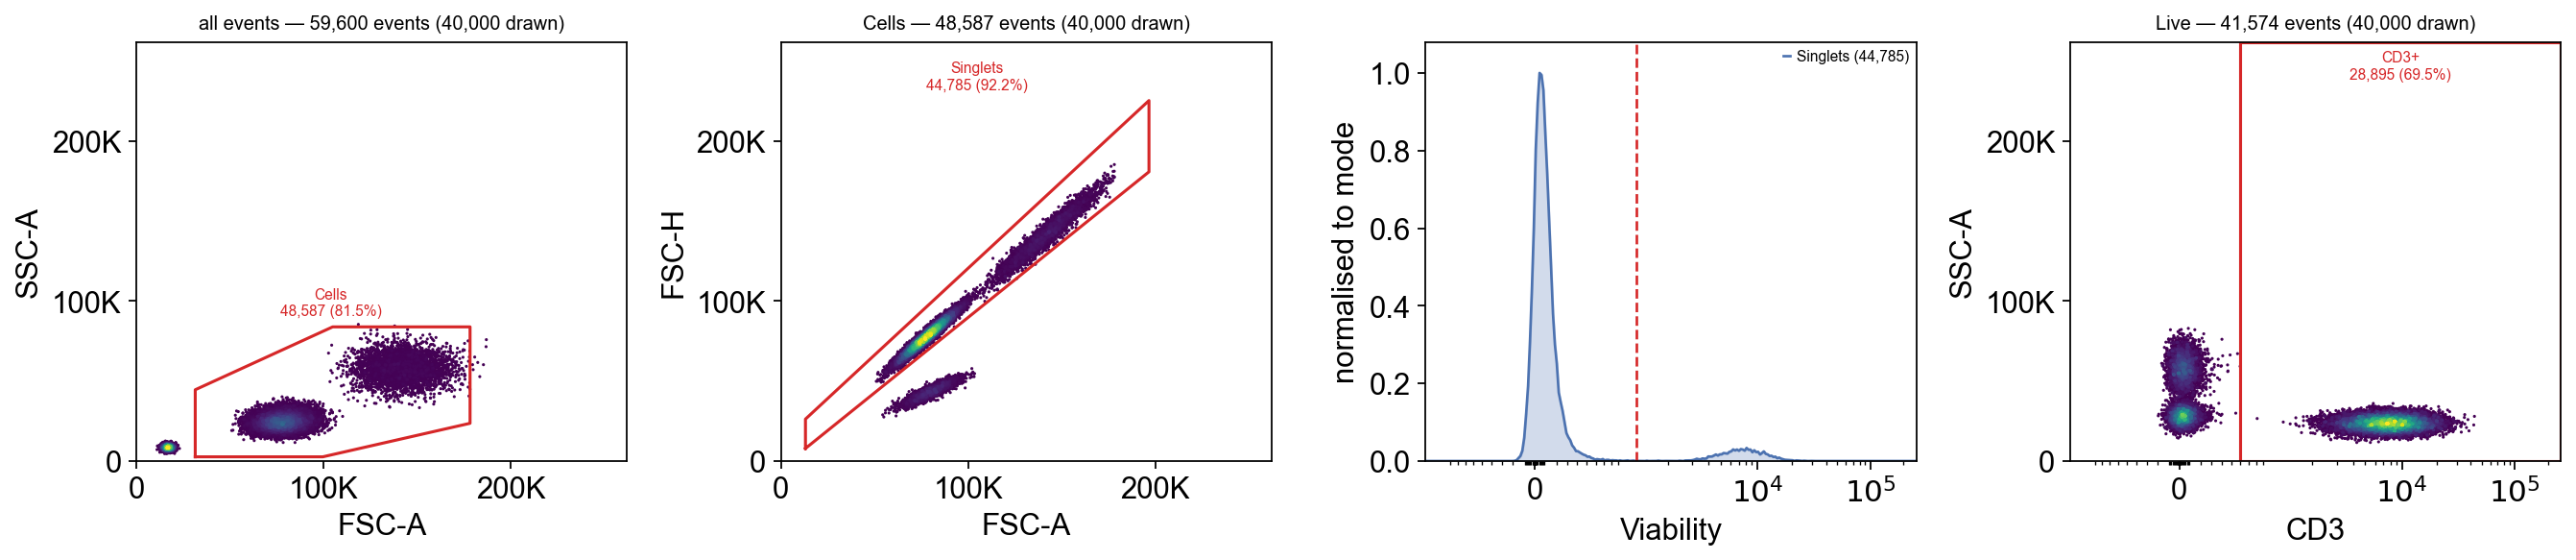

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(17, 3.9))

ov.flow.biaxial(adata, "FSC-A", "SSC-A", gates=[cells], result=res,
                ax=axes[0], max_events=40000)
ov.flow.biaxial(adata, "FSC-A", "FSC-H", gates=[singlets], result=res,
                population="Cells", ax=axes[1], max_events=40000)
ov.flow.histogram(adata, "Viability", gates=[live], result=res,
                  populations=["Singlets"], ax=axes[2])
ov.flow.biaxial(adata, "CD3", "SSC-A", gates=[cd3],
                transforms={"CD3": lg, "SSC-A": lin}, result=res,
                population="Live", ax=axes[3], max_events=40000)
plt.tight_layout()

### Does the singlet gate exclude anything?

A worthwhile question to ask of any gate, and one the picture answers only
approximately. Doublets have roughly the same pulse *area* as singlets but a
much lower pulse *height*, so they fall below the FSC-A ≈ FSC-H diagonal. Since
this sample is synthetic we can check the gate against the truth:

In [6]:
kept    = adata.obs["population"].to_numpy()[res.masks["Singlets"]]
n_in    = int((kept == "doublet").sum())
n_total = int((adata.obs["population"] == "doublet").sum())
print(f"doublets in the singlet gate: {n_in:,} of {n_total:,} "
      f"({n_in / n_total:.1%})")

doublets in the singlet gate: 0 of 3,800 (0.0%)


## The quadrant

A quadrant gate is **one** gate with several outputs, not four rectangles: the
quadrants share their dividers, so moving a divider must move every boundary at
once. Four independent gates drift apart the first time someone edits one.

The four corner percentages are the entire point of the plot.

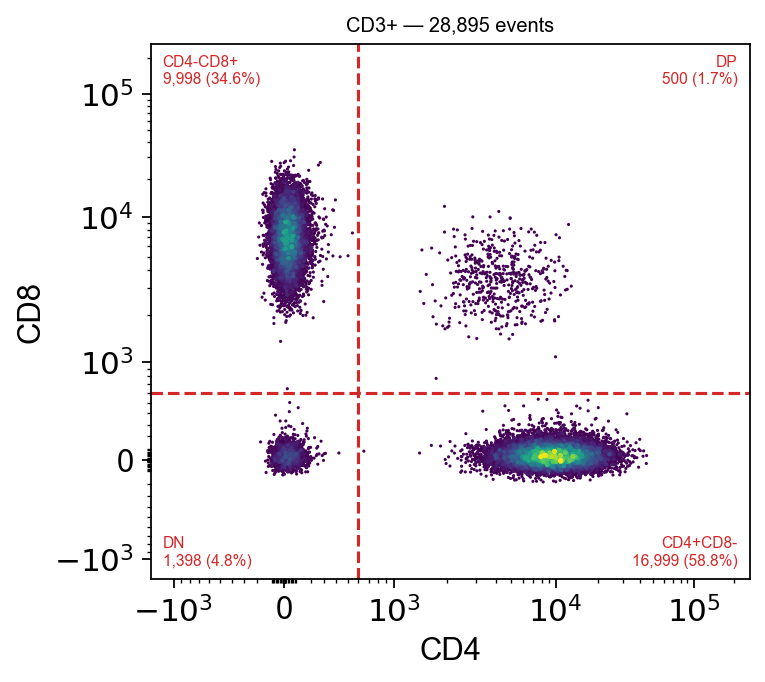

In [7]:
ov.flow.biaxial(adata, "CD4", "CD8", gates=[quad], result=res,
                population="CD3+", figsize=(4.8, 4.4), max_events=40000)
None

## The hierarchy

`gs.tree()` prints the same shape as text, which is better in a terminal. The
drawn version carries the numbers, and that is what a reader checks: a
population that keeps 3% of its parent where you expected 60% is obvious here
and invisible in a sorted table. Nodes below `min_events` are flagged.

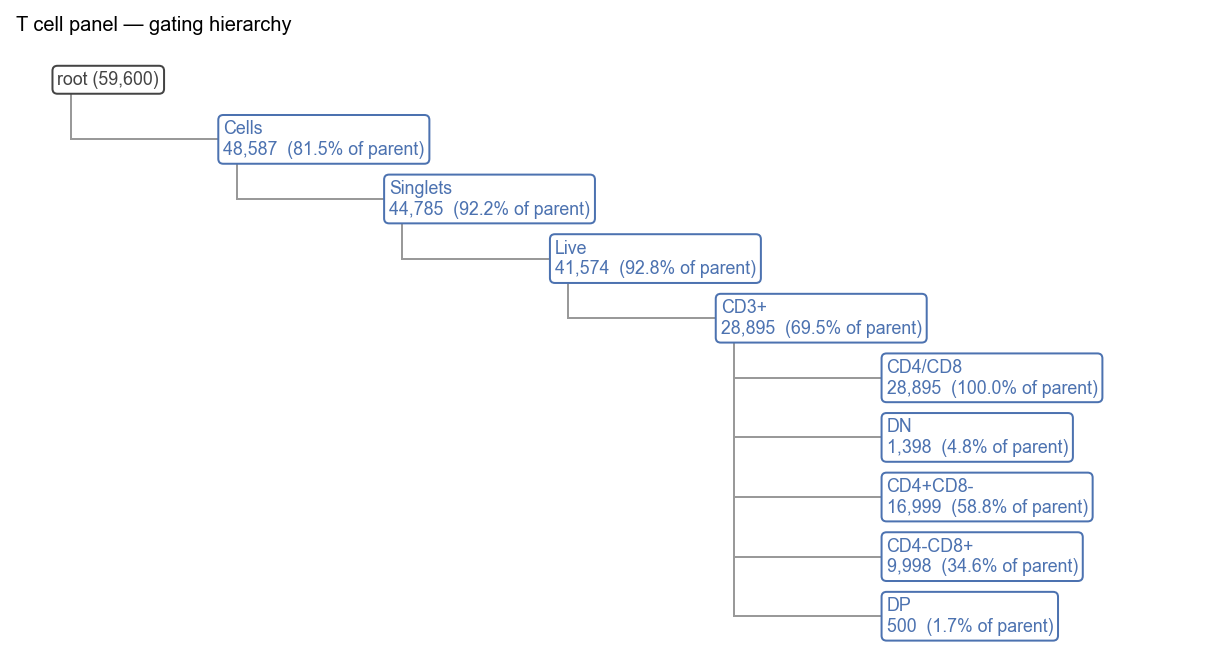

In [8]:
ov.flow.hierarchy(gs, result=res, figsize=(9.5, 5))
None

## Back-gating

The question that catches a bad gate: *where does this population sit on axes it
was never gated on?* A "CD4 T" population scattered through the debris corner of
FSC × SSC is not a T-cell population, however clean the CD4 × CD8 plot looked —
and no statistics table will tell you.

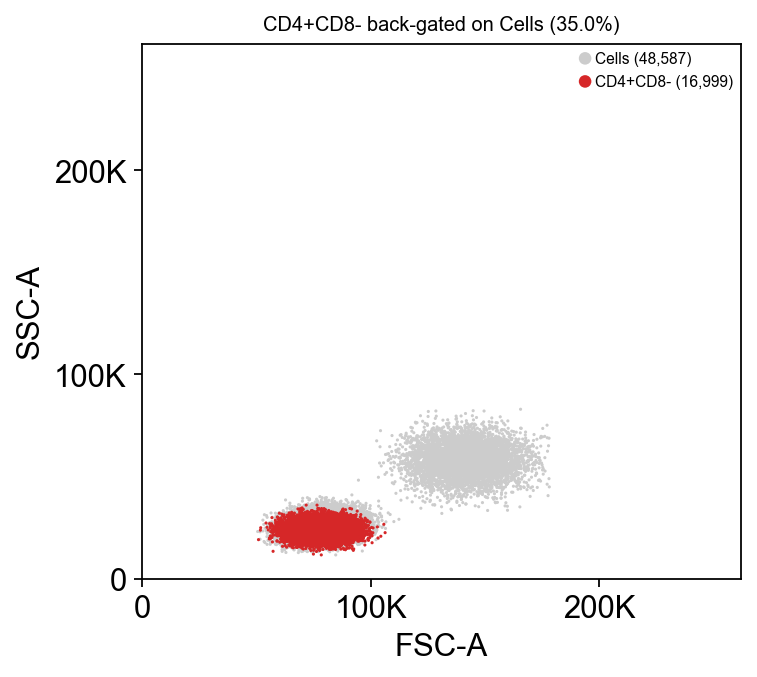

In [9]:
ov.flow.backgate(adata, "FSC-A", "SSC-A", result=res,
                 population="CD4+CD8-", parent="Cells",
                 transforms={"FSC-A": lin, "SSC-A": lin}, figsize=(4.8, 4.4))
None

## Boolean gates

`BooleanGate` composes populations that already exist, which is how "CD3+ but
not CD4+" is expressed without redrawing geometry. It is evaluated by the
strategy, since only the strategy knows what the referenced populations
resolved to.

Note that `not` is a separate gate: it takes exactly one operand, so "A and not
B" is two nodes rather than one. Verbose, but it means every intermediate is a
named population you can plot.

In [10]:
# dims=() because a boolean takes no dimensions of its own — it is evaluated
# by the strategy, the only thing that knows what its operands resolved to.
gs2 = ov.flow.GatingStrategy.from_dict(gs.to_dict())
gs2.add_gate(ov.flow.BooleanGate(name="not CD4", dims=(), operator="not",
                                 operands=("CD4+CD8-",)), parent="CD3+")
gs2.add_gate(ov.flow.BooleanGate(name="CD3+ non-CD4", dims=(), operator="and",
                                 operands=("CD3+", "not CD4")), parent="CD3+")

res2 = gs2.apply(adata.copy())
s2 = res2.stats().set_index("population")
print(f"CD3+          : {int(s2.loc['CD3+', 'count']):,}")
print(f"CD4+CD8-      : {int(s2.loc['CD4+CD8-', 'count']):,}")
print(f"CD3+ non-CD4  : {int(s2.loc['CD3+ non-CD4', 'count']):,}"
      f"   (= {int(s2.loc['CD3+', 'count']) - int(s2.loc['CD4+CD8-', 'count']):,})")

CD3+          : 28,895
CD4+CD8-      : 16,999
CD3+ non-CD4  : 11,896   (= 11,896)


## What is next

The strategy is an object, so it can be written to a file and applied to another
sample — [that is the next notebook](t_flow_03_gatingml.ipynb).